# Ejercicio 4 - Analisis exploratorio con DuckDB

Analisis de los viajes de taxis amarillos (yellow) y verdes (green) de enero a
agosto de 2026, consultando directamente los archivos Parquet con DuckDB.

Las consultas estan en `sql/04_analisis/` (un archivo por consulta, con su
objetivo y fuente en el encabezado). `00_vistas.sql` define las vistas
temporales que usan todas las demas (`viajes`, `viajes_validos`, `zonas`,
`metodos_pago`); son vistas, no tablas, por lo que cada consulta sigue leyendo
los Parquet.

La documentacion (preguntas, justificacion, resultados y hallazgos) esta en
`docs/04_analisis_exploratorio.md`. Las figuras se guardan en `docs/figuras/`.

| # | Pregunta | Consultas |
|---|----------|-----------|
| 1 | ¿Como se distribuye la demanda por hora y dia de la semana, y cambia el patron entre laborables y fines de semana? | 01-04 |
| 2 | ¿Cuales son las zonas con mas viajes y que caracteriza a los viajes de aeropuerto? | 05-08 |
| 3 | En los taxis verdes, ¿en que se diferencian los viajes tomados en la calle de los despachados? | 09-11 |
| 4 | ¿Como se paga, como cambia la propina segun el metodo de pago y de que depende la propina con tarjeta? | 12-16 |
| 5 | ¿Cuanto cuesta una milla segun la distancia del viaje y la hora? | 17-18 |
| 6 | ¿Se concentran los valores atipicos en algun proveedor o mes? | 19-21 |

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "scripts"))
from run_sql import conectar, encabezado

con = conectar()
DIR_SQL = RAIZ / "sql" / "04_analisis"
DIR_FIGURAS = RAIZ / "docs" / "figuras"
DIR_FIGURAS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.max_rows", 120)


def ejecutar(nombre: str) -> pd.DataFrame:
    """Muestra el encabezado de sql/04_analisis/<nombre> y devuelve su resultado."""
    ruta = DIR_SQL / nombre
    print(chr(10).join(encabezado(ruta)))
    inicio = time.perf_counter()
    resultado = con.sql(ruta.read_text(encoding="utf-8"))
    df = resultado.df() if resultado is not None else pd.DataFrame()
    print(f"-- tiempo: {time.perf_counter() - inicio:.2f} s")
    return df


# --- Estilo de los graficos -------------------------------------------------
# Colores de la paleta de referencia (skill dataviz). Los tipos de taxi usan
# el color del taxi (amarillo / verde), que ademas difieren mucho en
# luminosidad, por lo que se distinguen tambien con daltonismo. El amarillo
# tiene poco contraste sobre fondo claro: siempre va con leyenda o etiqueta.
COLOR_TIPO = {"yellow": "#eda100", "green": "#008300"}
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]   # azul, naranja, aqua (validos en todos los pares)
GRIS = "#898781"
TINTA, TINTA_2, REJILLA, EJE = "#0b0b0b", "#52514e", "#e1e0d9", "#c3c2b7"
AZUL_SECUENCIAL = LinearSegmentedColormap.from_list(
    "azul", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"])

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "font.family": "sans-serif", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_2, "axes.titlecolor": TINTA,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": GRIS, "ytick.color": GRIS, "axes.edgecolor": EJE,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 110,
})


def guardar(fig, nombre: str):
    fig.savefig(DIR_FIGURAS / f"{nombre}.png", dpi=130, bbox_inches="tight")


miles = mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")

# Vistas base: imprime cuantos viajes quedan despues de la limpieza.
ejecutar("00_vistas.sql")

-- Ejercicio 4 - Vistas base del analisis exploratorio
-- Objetivo: definir en un solo lugar (y dejar registradas) las
--           transformaciones que usan todas las consultas del ejercicio:
--             * viajes:          yellow + green con nombres de columna comunes
--             * viajes_validos:  viajes sin los registros invalidos detectados
--                                en el Ejercicio 3
--             * zonas:           tabla de zonas de la TLC
--             * metodos_pago:    nombres de los codigos de payment_type
-- Fuente:   data/raw/yellow/2026/*.parquet, data/raw/green/2026/*.parquet,
--           data/raw/zones/taxi_zone_lookup.csv
-- Nota:     son vistas TEMPORALES: no copian datos; cada consulta que las usa
--           vuelve a leer los Parquet. Este archivo debe ejecutarse antes que
--           los demas (run_sql.py y el notebook lo hacen por orden de nombre).


-- tiempo: 1.56 s


,tipo,viajes,viajes_validos,pct_validos
0,yellow,29703355,28242805,95.08
1,green,337114,324231,96.18


## Pregunta 1 - Comportamiento temporal

**¿Como se distribuye la demanda a lo largo del dia y de la semana, y cambia el
patron horario entre dias laborables y fines de semana?**

*Justificacion:* el volumen mensual es estable (3.3-4.1 M viajes yellow), por lo
que la variacion relevante esta dentro de la semana y del dia. Saber cuando se
concentra la demanda es la base para dimensionar la flota y para interpretar
el resto de variables (tarifa, propina, velocidad), que dependen de la hora.

In [2]:
dia_semana = ejecutar("01_viajes_por_dia_semana.sql")
dia_semana

-- Ejercicio 4 - Pregunta 1 (temporal): demanda por dia de la semana
-- Objetivo: comparar cuantos viajes hay, en promedio, cada dia de la semana
--           para yellow y green.
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/*/2026/*.parquet
-- Nota:     se usa el PROMEDIO de viajes por fecha (no el total), porque cada
--           dia de la semana aparece un numero distinto de veces entre enero y
--           agosto. isodow: 1 = lunes ... 7 = domingo.


-- tiempo: 1.19 s


,tipo,num_dia,dia,fechas,viajes_promedio,pct_vs_promedio_semana
0,yellow,1,Lun,35,95920.0,-17.5
1,yellow,2,Mar,34,113187.0,-2.6
2,yellow,3,Mie,34,120647.0,3.8
3,yellow,4,Jue,35,127450.0,9.7
4,yellow,5,Vie,35,120689.0,3.8
5,yellow,6,Sab,35,128672.0,10.7
6,yellow,7,Dom,35,107054.0,-7.9
7,green,1,Lun,35,1322.0,-1.0
8,green,2,Mar,34,1443.0,8.0
9,green,3,Mie,34,1496.0,12.1


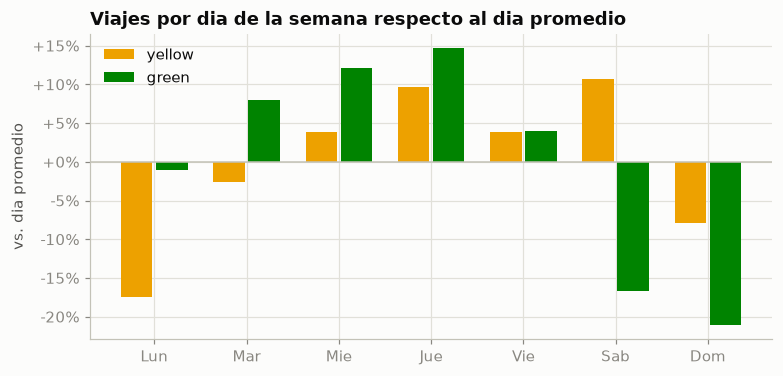

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ancho = 0.38
for i, tipo in enumerate(["yellow", "green"]):
    d = dia_semana[dia_semana.tipo == tipo]
    ax.bar(d.num_dia + (i - 0.5) * ancho, d.pct_vs_promedio_semana, width=ancho - 0.04,
           color=COLOR_TIPO[tipo], label=tipo)
ax.axhline(0, color=EJE, linewidth=1)
ax.set_xticks(range(1, 8), ["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax.set_ylabel("vs. dia promedio")
ax.set_title("Viajes por dia de la semana respecto al dia promedio")
ax.legend(loc="upper left")
guardar(fig, "ej4_p1_dia_semana")

In [4]:
por_hora = ejecutar("02_viajes_por_hora.sql")
por_hora.pivot_table(index="hora", columns=["tipo", "tipo_dia"], values="viajes_promedio")

-- Ejercicio 4 - Pregunta 1 (temporal): patron por hora, entre semana vs fin de semana
-- Objetivo: identificar las horas pico y verificar si el perfil horario
--           cambia entre dias laborables y fines de semana.
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/*/2026/*.parquet
-- Nota:     viajes promedio por hora = viajes en esa hora / numero de fechas
--           de ese tipo de dia (laborable o fin de semana), para que ambos
--           perfiles sean comparables aunque haya ~2.5 veces mas dias
--           laborables. pct_del_dia = parte de los viajes del dia que ocurre
--           en esa hora.


-- tiempo: 1.68 s


tipo             green                  yellow          
tipo_dia Fin de semana Laborable Fin de semana Laborable
hora                                                    
0                 32.0      15.0        6890.0    2459.0
1                 23.0       8.0        5421.0    1292.0
2                 20.0       4.0        3916.0     735.0
3                 18.0       3.0        2854.0     512.0
4                 14.0       5.0        1901.0     596.0
5                  8.0      11.0         981.0    1116.0
6                  9.0      35.0        1250.0    2336.0
7                 18.0      73.0        1607.0    4308.0
8                 26.0      91.0        2333.0    5710.0
9                 41.0      90.0        3553.0    5530.0
10                48.0      83.0        4529.0    5225.0
11                57.0      79.0        5377.0    5439.0
12                69.0      82.0        6036.0    5793.0
13                69.0      80.0        6443.0    6009.0
14                74.0      91.0        6578.0    6680.0
15                78.0     100.0        6522.0    7016.0
16                78.0     109.0        6762.0    6518.0
17                75.0     115.0        7029.0    7377.0
18                79.0     105.0        7317.0    7639.0
19                66.0      76.0        6812.0    6871.0
20                55.0      57.0        6026.0    7132.0
21                49.0      50.0        5947.0    7516.0
22                43.0      43.0        6098.0    6741.0
23                36.0      29.0        5682.0    5014.0

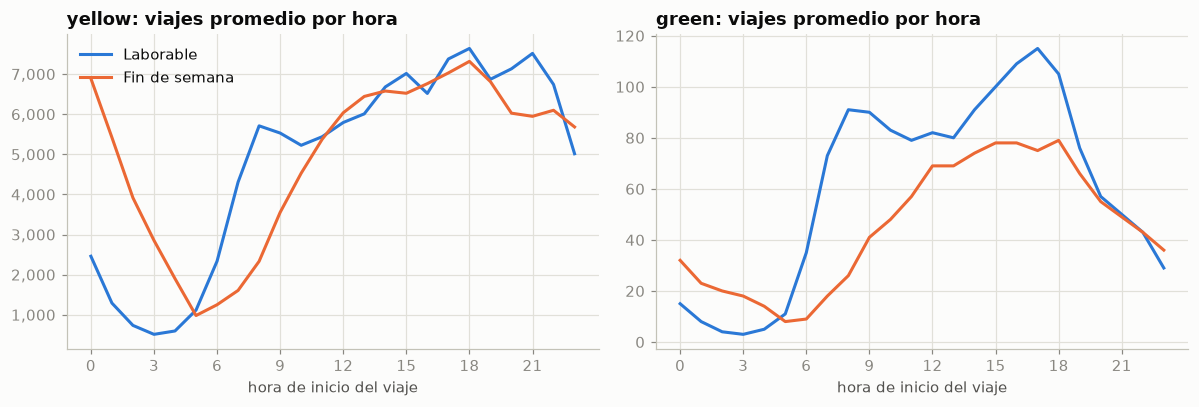

In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
for ax, tipo in zip(ejes, ["yellow", "green"]):
    for color, tipo_dia in zip(SERIES, ["Laborable", "Fin de semana"]):
        d = por_hora[(por_hora.tipo == tipo) & (por_hora.tipo_dia == tipo_dia)]
        ax.plot(d.hora, d.viajes_promedio, color=color, label=tipo_dia)
    ax.set_title(f"{tipo}: viajes promedio por hora")
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("hora de inicio del viaje")
    ax.yaxis.set_major_formatter(miles)
ejes[0].legend(loc="upper left")
fig.tight_layout()
guardar(fig, "ej4_p1_por_hora")

-- Ejercicio 4 - Pregunta 1 (temporal): mapa de calor dia de la semana x hora
-- Objetivo: ubicar las franjas (dia + hora) con mayor y menor demanda,
--           combinando las dos consultas anteriores.
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/*/2026/*.parquet
-- Nota:     formato largo (una fila por tipo, dia y hora); el notebook lo
--           pivotea para dibujar el mapa. Valor = viajes promedio por fecha.


-- tiempo: 2.63 s


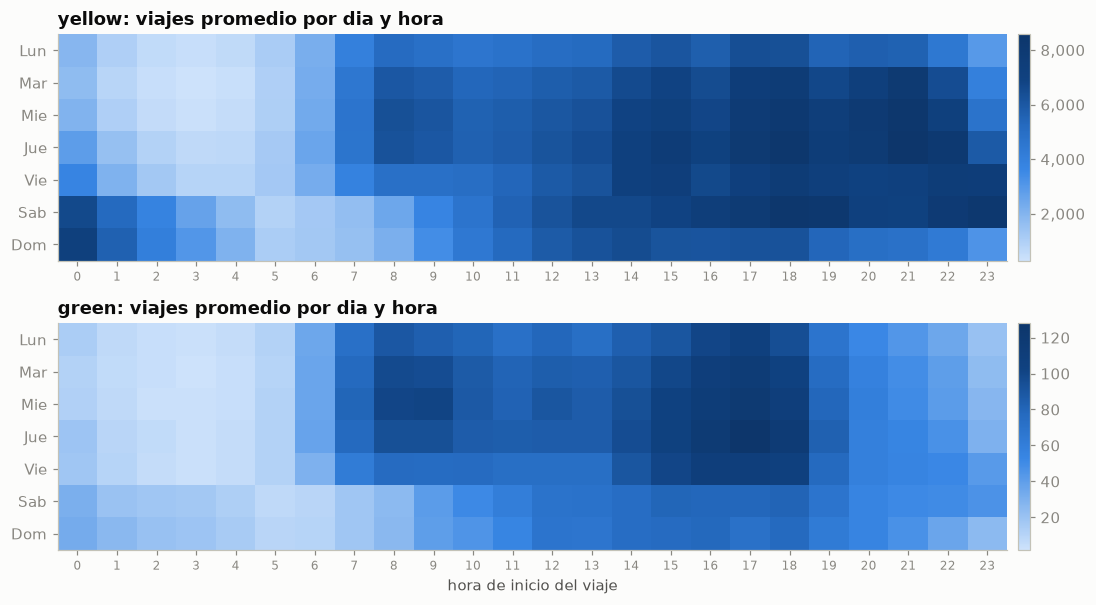

In [6]:
mapa = ejecutar("03_mapa_calor_dia_hora.sql")
fig, ejes = plt.subplots(2, 1, figsize=(11, 5.6))
for ax, tipo in zip(ejes, ["yellow", "green"]):
    m = mapa[mapa.tipo == tipo].pivot(index="dia", columns="hora", values="viajes_promedio")
    m = m.loc[["Lun", "Mar", "Mie", "Jue", "Vie", "Sab", "Dom"]]
    img = ax.imshow(m.values, aspect="auto", cmap=AZUL_SECUENCIAL)
    ax.set_yticks(range(7), m.index)
    ax.set_xticks(range(24), range(24), fontsize=8)
    ax.grid(False)
    ax.set_title(f"{tipo}: viajes promedio por dia y hora")
    fig.colorbar(img, ax=ax, format=miles, pad=0.01)
ejes[1].set_xlabel("hora de inicio del viaje")
fig.tight_layout()
guardar(fig, "ej4_p1_mapa_calor")

In [7]:
ejecutar("04_franjas_extremas.sql")

-- Ejercicio 4 - Pregunta 1 (temporal): franjas de mayor y menor demanda
-- Objetivo: listar, para cada tipo de taxi, las 5 combinaciones dia + hora
--           con mas viajes promedio y las 5 con menos, y cuanto representan
--           respecto a la franja promedio.
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/*/2026/*.parquet


-- tiempo: 2.37 s


,tipo,grupo,posicion,franja,viajes_promedio,veces_el_promedio
0,yellow,mayor demanda,1,Jue 21h,8583.0,1.77
1,yellow,mayor demanda,2,Sab 18h,8412.0,1.74
2,yellow,mayor demanda,3,Mie 21h,8401.0,1.73
3,yellow,mayor demanda,4,Jue 18h,8384.0,1.73
4,yellow,mayor demanda,5,Sab 19h,8242.0,1.70
5,yellow,menor demanda,1,Mar 03h,284.0,0.06
6,yellow,menor demanda,2,Mie 03h,358.0,0.07
7,yellow,menor demanda,3,Mar 04h,403.0,0.08
8,yellow,menor demanda,4,Mar 02h,429.0,0.09
9,yellow,menor demanda,5,Lun 03h,434.0,0.09


## Pregunta 2 - Zonas y viajes de aeropuerto

**¿Cuales son las zonas donde mas viajes empiezan y terminan, y que
caracteriza a los viajes que salen o llegan a los aeropuertos?**

*Justificacion:* los datos traen origen y destino de cada viaje
(`PULocationID`, `DOLocationID`) y una tarifa fija y un cargo exclusivos de
aeropuerto (`RatecodeID = 2`, `Airport_fee`), lo que indica que los aeropuertos
son un segmento con reglas propias. Para leer las zonas se descargo la tabla de
zonas de la TLC (`data/raw/zones/taxi_zone_lookup.csv`).

In [8]:
zonas_top = ejecutar("05_zonas_principales.sql")
zonas_top

-- Ejercicio 4 - Pregunta 2 (zonas): zonas con mas viajes de origen y destino
-- Objetivo: identificar las 10 zonas donde mas viajes empiezan y terminan
--           para cada tipo de taxi, con su distrito y su participacion.
-- Fuente:   vista viajes_validos + vista zonas (00_vistas.sql)
--           -> data/raw/*/2026/*.parquet, data/raw/zones/taxi_zone_lookup.csv
-- Nota:     el porcentaje es sobre el total de viajes validos del tipo de
--           taxi (incluyendo zonas 264/265, que aparecen si estan en el top).


-- tiempo: 4.29 s


,tipo,rol,posicion,zona,distrito,viajes,pct,pct_acumulado
0,yellow,origen,1,Upper East Side South,Manhattan,1253197,4.44,4.44
1,yellow,origen,2,Midtown Center,Manhattan,1171986,4.15,8.59
2,yellow,origen,3,JFK Airport,Queens,1126027,3.99,12.57
3,yellow,origen,4,Upper East Side North,Manhattan,1113603,3.94,16.52
4,yellow,origen,5,Penn Station/Madison Sq West,Manhattan,868861,3.08,19.59
5,yellow,origen,6,Midtown East,Manhattan,864869,3.06,22.66
6,yellow,origen,7,Times Sq/Theatre District,Manhattan,817756,2.90,25.55
7,yellow,origen,8,Lincoln Square East,Manhattan,812020,2.88,28.43
8,yellow,origen,9,East Village,Manhattan,756668,2.68,31.11
9,yellow,origen,10,Murray Hill,Manhattan,737938,2.61,33.72


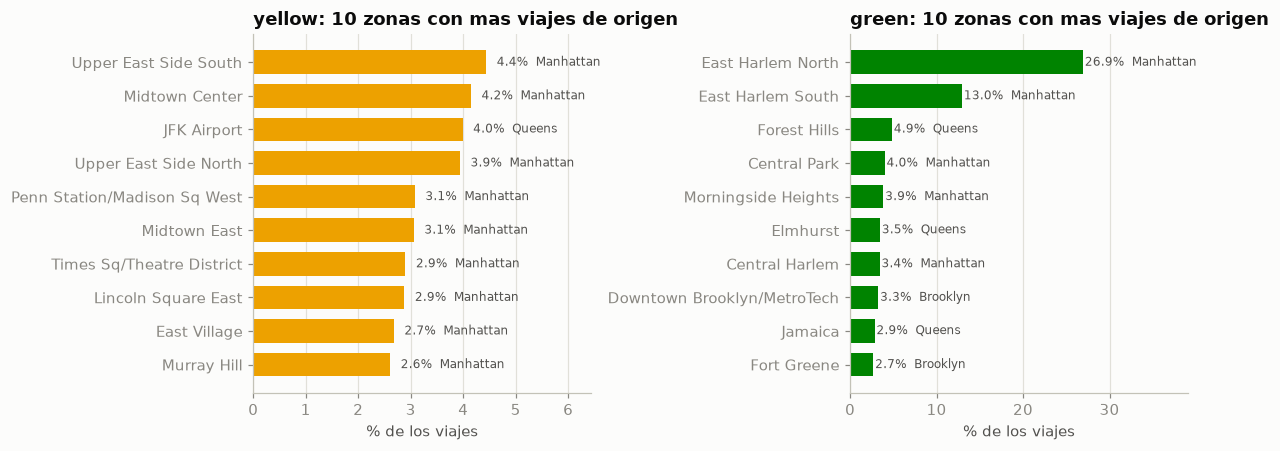

In [9]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, tipo in zip(ejes, ["yellow", "green"]):
    d = zonas_top[(zonas_top.tipo == tipo) & (zonas_top.rol == "origen")].iloc[::-1]
    ax.barh(d.zona, d.pct, color=COLOR_TIPO[tipo], height=0.7)
    for y, (pct, distrito) in enumerate(zip(d.pct, d.distrito)):
        ax.text(pct + 0.2, y, f"{pct:.1f}%  {distrito}", va="center", fontsize=8, color=TINTA_2)
    ax.set_title(f"{tipo}: 10 zonas con mas viajes de origen")
    ax.set_xlabel("% de los viajes")
    ax.set_xlim(0, d.pct.max() * 1.45)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
guardar(fig, "ej4_p2_zonas_origen")

In [10]:
ejecutar("06_viajes_por_distrito.sql")

-- Ejercicio 4 - Pregunta 2 (zonas): distribucion de origenes por distrito
-- Objetivo: ver en que distritos (boroughs) operan yellow y green; complementa
--           el top de zonas con una vista agregada.
-- Fuente:   vista viajes_validos + vista zonas (00_vistas.sql)
-- Nota:     'Unknown' y 'N/A' corresponden a las zonas 264 y 265.


-- tiempo: 2.29 s


,tipo,distrito_origen,viajes,pct
0,yellow,Manhattan,24467687,86.63
1,yellow,Queens,2499435,8.85
2,yellow,Brooklyn,1017344,3.60
3,yellow,Bronx,218959,0.78
4,yellow,Unknown,29488,0.10
5,yellow,N/A,6304,0.02
6,yellow,Staten Island,2675,0.01
7,yellow,EWR,913,0.00
8,green,Manhattan,192720,59.44
9,green,Queens,71546,22.07


In [11]:
aeropuerto = ejecutar("07_viajes_aeropuerto.sql")
aeropuerto

-- Ejercicio 4 - Pregunta 2 (aeropuertos): caracteristicas de los viajes de aeropuerto
-- Objetivo: cuantificar los viajes que salen o llegan a JFK, LaGuardia y
--           Newark y compararlos con el resto en distancia, duracion, tarifa,
--           total, propina y uso de la tarifa fija de JFK (RatecodeID = 2).
-- Fuente:   vista viajes_validos + vista zonas (00_vistas.sql)
-- Nota:     un viaje es "de aeropuerto" si su origen o su destino es una de
--           las zonas 1 (Newark), 132 (JFK) o 138 (LaGuardia). Si empieza y
--           termina en aeropuertos se clasifica por el origen. El porcentaje
--           de propina se calcula solo para pagos con tarjeta (las propinas en
--           efectivo no se registran) sobre el monto antes de la propina.


-- tiempo: 9.76 s


,tipo,categoria,viajes,pct_viajes,distancia_mediana,duracion_mediana_min,tarifa_mediana,total_mediano,pct_propina_mediana_tarjeta,pct_tarifa_fija_jfk,pct_ingresos
0,yellow,Desde JFK Airport,1126027,3.99,16.90,40.1,70.00,86.75,19.5,45.4,10.49
1,yellow,Desde LaGuardia Airport,716555,2.54,9.36,29.4,42.90,69.94,19.4,0.5,5.92
2,yellow,Hacia LaGuardia Airport,232950,0.82,9.90,28.0,44.30,69.91,20.0,0.2,1.91
3,yellow,Hacia JFK Airport,182010,0.64,16.99,50.4,70.00,95.46,20.0,67.7,1.97
4,yellow,Hacia Newark Airport,47756,0.17,17.36,37.5,93.00,131.70,20.0,0.1,0.74
5,yellow,Desde Newark Airport,913,0.00,0.05,0.2,114.00,127.20,12.1,0.5,0.01
6,yellow,Sin aeropuerto,25936594,91.83,1.78,13.3,14.90,22.45,20.0,0.1,78.96
7,green,Hacia LaGuardia Airport,8326,2.57,3.98,13.2,20.50,33.72,20.0,0.1,4.05
8,green,Hacia JFK Airport,2213,0.68,14.58,38.8,64.13,75.37,20.0,23.3,1.91
9,green,Hacia Newark Airport,165,0.05,21.56,44.8,110.00,143.76,20.0,0.0,0.29


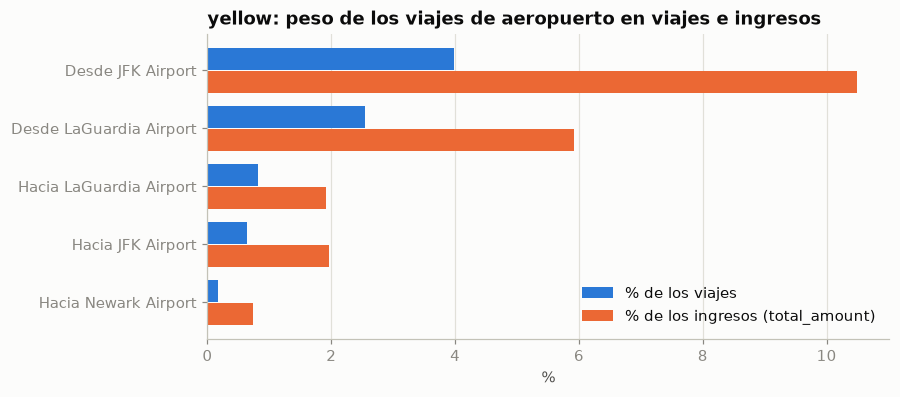

In [12]:
d = aeropuerto[(aeropuerto.tipo == "yellow") & (aeropuerto.categoria != "Sin aeropuerto")]
d = d[d.viajes > 10_000].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = range(len(d))
ax.barh([i + 0.2 for i in y], d.pct_viajes, height=0.38, color=SERIES[0], label="% de los viajes")
ax.barh([i - 0.2 for i in y], d.pct_ingresos, height=0.38, color=SERIES[1], label="% de los ingresos (total_amount)")
ax.set_yticks(list(y), d.categoria)
ax.set_xlabel("%")
ax.set_title("yellow: peso de los viajes de aeropuerto en viajes e ingresos")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
guardar(fig, "ej4_p2_aeropuertos")

-- Ejercicio 4 - Pregunta 2 (aeropuertos): horario de los viajes de aeropuerto
-- Objetivo: comparar el perfil horario de los viajes desde/hacia aeropuertos
--           con el del resto de viajes (taxis amarillos).
-- Fuente:   vista viajes_validos (00_vistas.sql)
-- Nota:     pct_del_grupo = parte de los viajes de cada grupo que ocurre en
--           esa hora, para comparar perfiles de distinto tamanio.


-- tiempo: 2.25 s


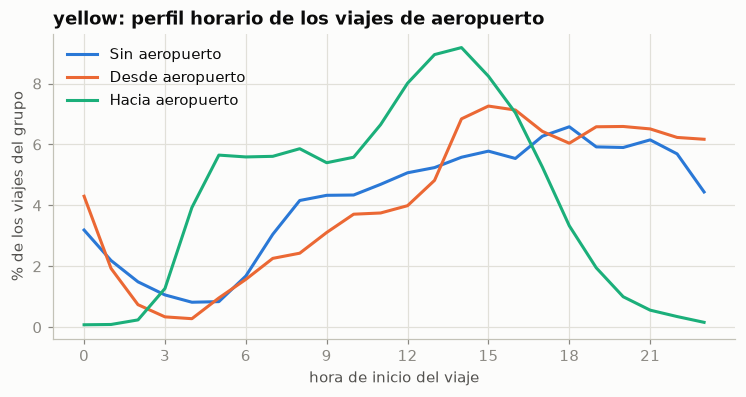

In [13]:
aero_hora = ejecutar("08_aeropuerto_por_hora.sql")
fig, ax = plt.subplots(figsize=(8, 3.6))
for color, grupo in zip(SERIES, ["Sin aeropuerto", "Desde aeropuerto", "Hacia aeropuerto"]):
    g = aero_hora[aero_hora.grupo == grupo]
    ax.plot(g.hora, g.pct_del_grupo, color=color, label=grupo)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hora de inicio del viaje")
ax.set_ylabel("% de los viajes del grupo")
ax.set_title("yellow: perfil horario de los viajes de aeropuerto")
ax.legend(loc="upper left")
guardar(fig, "ej4_p2_aeropuerto_hora")

## Pregunta 3 - Taxis verdes: calle vs despacho

**En los taxis verdes, ¿en que se diferencian los viajes tomados en la calle
(`trip_type = 1`) de los despachados (`trip_type = 2`)?**

*Justificacion:* `trip_type` es una columna exclusiva de green que describe dos
formas distintas de conseguir un viaje. Ademas, el Ejercicio 3 mostro que el
14.5% de green no tiene `trip_type` ni `payment_type`, por lo que se analiza
tambien ese tercer grupo.

In [14]:
ejecutar("09_green_tipo_viaje.sql")

-- Ejercicio 4 - Pregunta 3 (green): viajes tomados en la calle vs despachados
-- Objetivo: comparar los viajes de taxis verdes segun trip_type:
--           1 = tomado en la calle (street-hail), 2 = despachado (dispatch).
--           Se agrega un tercer grupo con trip_type NULL, que corresponde a
--           los viajes sin payment_type (equivalente a Flex Fare, ver
--           Ejercicio 3).
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/green/2026/*.parquet
-- Nota:     porcentaje de propina solo con tarjeta, sobre el monto antes de
--           la propina. codigo_tarifa 5 = tarifa negociada.


-- tiempo: 0.30 s


,grupo,viajes,pct_viajes,distancia_mediana,duracion_mediana_min,tarifa_mediana,total_mediano,pct_tarifa_negociada,pct_tarjeta,pct_efectivo,pct_propina_mediana_tarjeta,pasajeros_promedio,pct_proveedor_6_myle,pct_con_origen_solicitud
0,1 Calle,266102,82.07,1.93,12.3,13.5,19.60,0.7,76.6,23.1,20.0,1.29,0.0,0.0
1,2 Despacho,10452,3.22,4.05,15.0,40.0,49.20,99.8,84.3,14.2,13.0,1.41,0.0,0.0
2,3 Sin registro (NULL),47677,14.70,5.01,25.9,3.0,26.47,0.0,0.0,0.0,NaN,NaN,73.1,39.0


-- Ejercicio 4 - Pregunta 3 (green): perfil horario por tipo de viaje
-- Objetivo: verificar si los viajes despachados y los tomados en la calle
--           ocurren a horas distintas.
-- Fuente:   vista viajes_validos (00_vistas.sql) -> data/raw/green/2026/*.parquet
-- Nota:     pct_del_grupo = parte de los viajes de cada grupo en esa hora.


-- tiempo: 0.21 s


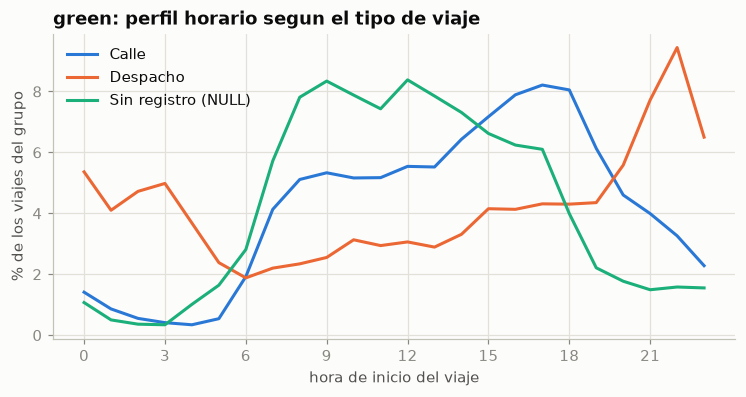

In [15]:
green_hora = ejecutar("10_green_tipo_viaje_por_hora.sql")
fig, ax = plt.subplots(figsize=(8, 3.6))
for color, grupo in zip(SERIES, sorted(green_hora.grupo.unique())):
    g = green_hora[green_hora.grupo == grupo]
    ax.plot(g.hora, g.pct_del_grupo, color=color, label=grupo[2:])
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hora de inicio del viaje")
ax.set_ylabel("% de los viajes del grupo")
ax.set_title("green: perfil horario segun el tipo de viaje")
ax.legend(loc="upper left")
guardar(fig, "ej4_p3_green_hora")

In [16]:
ejecutar("11_green_tipo_viaje_zonas.sql")

-- Ejercicio 4 - Pregunta 3 (green): zonas de origen por tipo de viaje
-- Objetivo: identificar las 5 zonas de origen mas frecuentes de cada grupo
--           de trip_type y que tan concentrado esta cada grupo.
-- Fuente:   vista viajes_validos + vista zonas (00_vistas.sql)


-- tiempo: 0.21 s


,grupo,posicion,zona,distrito,viajes,pct,pct_acumulado
0,1 Calle,1,East Harlem North,Manhattan,85327,32.07,32.07
1,1 Calle,2,East Harlem South,Manhattan,39840,14.97,47.04
2,1 Calle,3,Forest Hills,Queens,14762,5.55,52.58
3,1 Calle,4,Central Park,Manhattan,12868,4.84,57.42
4,1 Calle,5,Morningside Heights,Manhattan,11556,4.34,61.76
5,2 Despacho,1,Jamaica,Queens,991,9.48,9.48
6,2 Despacho,2,Flushing Meadows-Corona Park,Queens,905,8.66,18.14
7,2 Despacho,3,Downtown Brooklyn/MetroTech,Brooklyn,635,6.08,24.22
8,2 Despacho,4,Maspeth,Queens,614,5.87,30.09
9,2 Despacho,5,DUMBO/Vinegar Hill,Brooklyn,529,5.06,35.15


## Pregunta 4 - Pago y propinas

**¿Como pagan los pasajeros, como cambia la propina segun el metodo de pago y
de que depende la propina cuando se paga con tarjeta (hora, dia, distancia,
pasajeros)?**

*Justificacion:* el Ejercicio 3 mostro que el 26% de los viajes yellow son
"Flex Fare" (`payment_type = 0`), un metodo poco conocido, y que los nulos de
varias columnas dependen del metodo de pago. La propina es la variable de pago
con mas variacion y su registro depende del medio de pago.

In [17]:
pagos_mes = ejecutar("12_metodos_pago_por_mes.sql")
pagos_mes.pivot_table(index="mes", columns=["tipo", "metodo_pago"], values="pct_del_mes")

-- Ejercicio 4 - Pregunta 4 (pago): metodos de pago por mes
-- Objetivo: medir la participacion de cada metodo de pago por tipo de taxi
--           y mes, y ver si cambia en el tiempo.
-- Fuente:   vista viajes + vista metodos_pago (00_vistas.sql)
-- Nota:     se usa la vista viajes (no viajes_validos) limitada a 2026,
--           porque los filtros de validez eliminan montos negativos y con
--           ellos la mayoria de las disputas; aqui interesa la mezcla real de
--           metodos. En green, payment_type NULL se etiqueta 'Sin dato (NULL)'.


-- tiempo: 1.11 s


tipo          green                                                 yellow                                             
metodo_pago Disputa Efectivo Sin cargo Sin dato (NULL) Tarjeta Desconocido Disputa Efectivo Flex Fare Sin cargo Tarjeta
mes                                                                                                                    
2026-01        0.23    20.60      0.59           13.45   65.13         NaN    1.51     8.43     29.21      0.45   60.40
2026-02        0.24    20.17      0.64           14.41   64.54         NaN    1.14     8.05     30.10      0.36   60.35
2026-03        0.17    19.48      0.51           15.14   64.70         NaN    0.80     8.94     23.93      0.32   66.01
2026-04        0.22    19.28      0.54           14.22   65.74         NaN    0.60     9.42     20.88      0.31   68.80
2026-05        0.22    19.83      0.45           12.85   66.65         NaN    0.56     9.12     23.35      0.29   66.68
2026-06        0.21    19.09      0.45           14.66   65.59         0.0    0.57     9.32     26.41      0.29   63.40
2026-07        0.24    18.31      0.43           15.60   65.42         NaN    0.61     9.79     27.47      0.31   61.82
2026-08        0.25    19.77      0.42           15.52   64.04         NaN    0.71     9.87     27.61      0.31   61.50

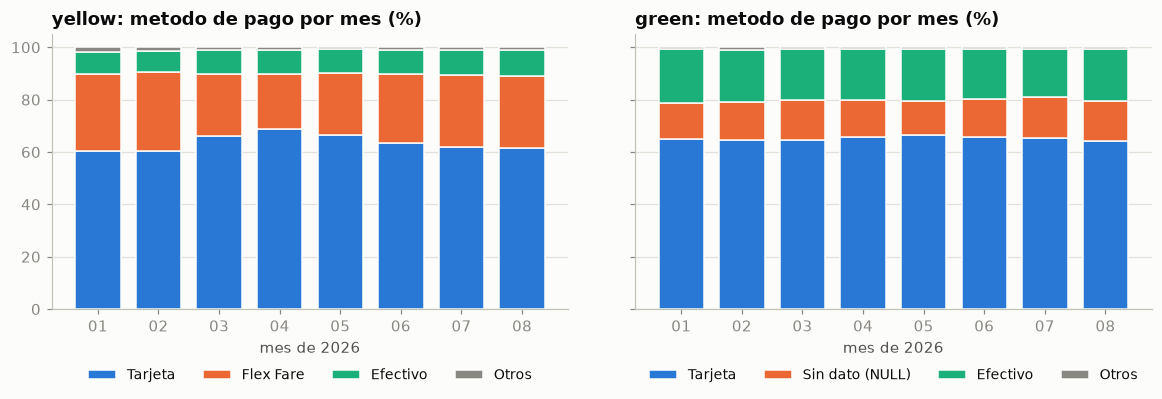

In [18]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, tipo in zip(ejes, ["yellow", "green"]):
    d = pagos_mes[pagos_mes.tipo == tipo].copy()
    principales = ["Tarjeta", "Flex Fare" if tipo == "yellow" else "Sin dato (NULL)", "Efectivo"]
    d["metodo"] = d.metodo_pago.where(d.metodo_pago.isin(principales), "Otros")
    p = d.pivot_table(index="mes", columns="metodo", values="pct_del_mes", aggfunc="sum")[principales + ["Otros"]]
    base = pd.Series(0.0, index=p.index)
    for color, metodo in zip(SERIES + [GRIS], p.columns):
        ax.bar(range(len(p)), p[metodo], bottom=base, color=color, width=0.75, label=metodo,
               edgecolor="#fcfcfb", linewidth=1)
        base += p[metodo]
    ax.set_xticks(range(len(p)), [m[5:] for m in p.index])
    ax.set_xlabel("mes de 2026")
    ax.set_title(f"{tipo}: metodo de pago por mes (%)")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), fontsize=9, ncols=4)
    ax.grid(axis="x", visible=False)
fig.tight_layout()
guardar(fig, "ej4_p4_metodos_pago")

In [19]:
ejecutar("13_flex_fare_origen_solicitud.sql")

-- Ejercicio 4 - Pregunta 4 (pago): de donde vienen los viajes Flex Fare
-- Objetivo: caracterizar los viajes con payment_type = 0 (Flex Fare) usando
--           request_source, columna que existe desde 2026-06, y compararlos
--           con los pagos con tarjeta y efectivo.
-- Fuente:   vista viajes_validos + vista metodos_pago (00_vistas.sql)
--           -> data/raw/yellow/2026/yellow_tripdata_2026-0[6-8].parquet
-- Nota:     request_source no aparece en el diccionario de datos de la TLC.
--           HV0003 y HV0005 coinciden con los codigos de licencia HVFHS de la
--           TLC (Uber y Lyft); el resto de codigos (A, CC, EH*) no tiene
--           documentacion publica disponible.


-- tiempo: 1.66 s


,metodo_pago,origen_solicitud,viajes,pct_del_metodo,distancia_mediana,total_mediano,pct_con_propina
0,Efectivo,NULL,980631,100.00,1.64,18.95,0.0
1,Flex Fare,HV0003,2092373,79.25,3.03,28.54,2.0
2,Flex Fare,A,363667,13.77,3.70,29.90,38.2
3,Flex Fare,HV0005,162315,6.15,4.87,30.03,0.0
4,Flex Fare,EH0004,19599,0.74,2.50,23.91,0.0
5,Flex Fare,CC,1516,0.06,1.71,27.06,97.5
6,Flex Fare,NULL,877,0.03,2.00,21.33,97.3
7,Flex Fare,EH0010,1,0.00,1.60,16.85,0.0
8,Tarjeta,NULL,6486814,100.00,1.70,22.32,92.7


In [20]:
ejecutar("14_propina_por_metodo.sql")

-- Ejercicio 4 - Pregunta 4 (pago): propina segun el metodo de pago
-- Objetivo: comparar cuantos viajes registran propina y de que tamanio,
--           segun el metodo de pago y el tipo de taxi.
-- Fuente:   vista viajes_validos + vista metodos_pago (00_vistas.sql)
-- Nota:     pct_propina = propina / (total - propina), es decir, la propina
--           como porcentaje de lo cobrado antes de ella (asi la calculan las
--           pantallas de pago de los taxis).


-- tiempo: 5.02 s


,tipo,metodo_pago,viajes,viajes_con_propina,pct_con_propina,propina_promedio,propina_mediana_si_hay,pct_propina_mediana_si_hay
0,yellow,Tarjeta,18461107,16821288,91.12,4.26,3.51,20.0
1,yellow,Flex Fare,7044806,582448,8.27,0.40,3.94,16.5
2,yellow,Efectivo,2560893,172,0.01,0.00,3.59,20.0
3,yellow,Disputa,119058,31,0.03,0.00,5.00,20.0
4,yellow,Sin cargo,56940,10,0.02,0.00,3.54,20.0
5,yellow,Desconocido,1,0,0.00,0.00,NaN,NaN
6,green,Tarjeta,212519,194105,91.34,3.81,3.35,20.0
7,green,Efectivo,62931,0,0.00,0.00,NaN,NaN
8,green,Sin dato (NULL),47677,7364,15.45,0.76,3.90,19.8
9,green,Sin cargo,775,2,0.26,0.00,1.81,20.0


-- Ejercicio 4 - Pregunta 4 (pago): propina segun la hora y el tipo de dia
-- Objetivo: verificar si la propina cambia a lo largo del dia y entre dias
--           laborables y fines de semana.
-- Fuente:   vista viajes_validos (00_vistas.sql)
-- Nota:     solo pagos con tarjeta (payment_type = 1): en efectivo la
--           propina casi nunca se registra (ver consulta 14), por lo que
--           incluirlo mezclaria comportamiento con forma de registro. Se usa
--           el promedio del porcentaje recortado a [0, 100] para que viajes
--           con total casi cero no distorsionen el resultado.


-- tiempo: 1.79 s


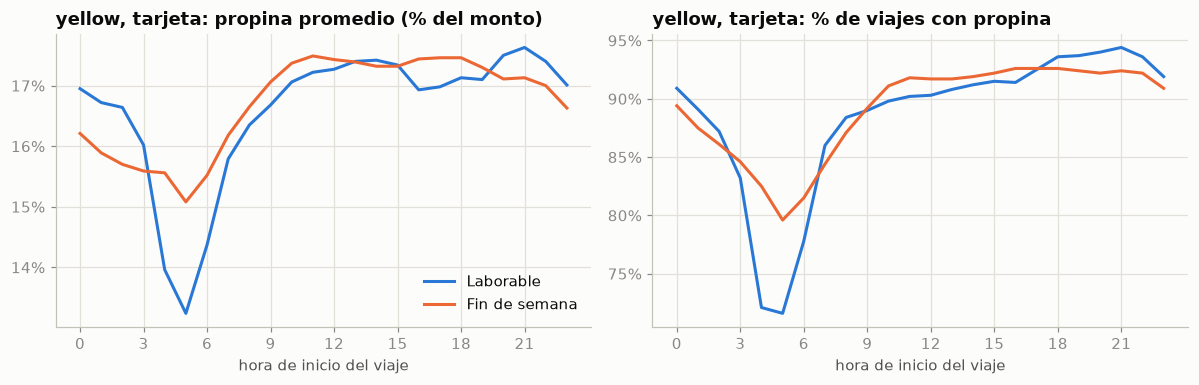

In [21]:
propina_hora = ejecutar("15_propina_por_hora_y_dia.sql")
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
d = propina_hora[propina_hora.tipo == "yellow"]
for color, tipo_dia in zip(SERIES, ["Laborable", "Fin de semana"]):
    g = d[d.tipo_dia == tipo_dia]
    ejes[0].plot(g.hora, g.pct_propina_promedio, color=color, label=tipo_dia)
    ejes[1].plot(g.hora, g.pct_con_propina, color=color, label=tipo_dia)
ejes[0].set_title("yellow, tarjeta: propina promedio (% del monto)")
ejes[1].set_title("yellow, tarjeta: % de viajes con propina")
for ax in ejes:
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("hora de inicio del viaje")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ejes[0].legend(loc="lower right")
fig.tight_layout()
guardar(fig, "ej4_p4_propina_hora")

-- Ejercicio 4 - Pregunta 4 (pago): propina segun distancia y pasajeros
-- Objetivo: ver si la propina (en USD y en %) cambia con la distancia del
--           viaje y con el numero de pasajeros.
-- Fuente:   vista viajes_validos (00_vistas.sql)
-- Nota:     solo pagos con tarjeta y solo yellow (green tiene muy pocos
--           viajes en los rangos largos). pasajeros = 0 o NULL se agrupa como
--           'Sin dato'; 5 o mas se agrupan.


-- tiempo: 3.70 s


,dimension,rango,viajes,pct_con_propina,propina_mediana,pct_propina_promedio
0,distancia,1) < 1 mi,4396409,94.1,2.39,18.21
1,distancia,2) 1-2 mi,6127007,94.5,3.15,17.64
2,distancia,3) 2-5 mi,4755312,91.4,4.41,16.76
3,distancia,4) 5-10 mi,1637276,81.4,7.28,14.95
4,distancia,5) 10-20 mi,1364202,79.0,12.44,14.44
5,distancia,6) >= 20 mi,180901,78.7,16.29,13.81
6,pasajeros,0) Sin dato,75163,93.9,3.05,17.37
7,pasajeros,1) 1,15265456,90.6,3.23,16.94
8,pasajeros,2) 2,2236415,94.3,3.58,17.59
9,pasajeros,3) 3,495546,92.6,3.51,17.21


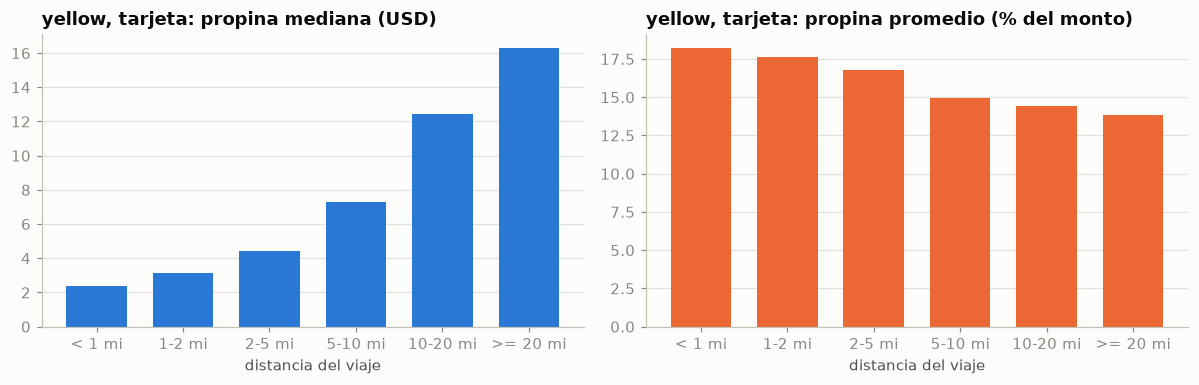

In [22]:
propina_dist = ejecutar("16_propina_por_distancia_y_pasajeros.sql")
d = propina_dist[propina_dist.dimension == "distancia"]
etiquetas = [r.split(") ")[1] for r in d.rango]
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6))
ejes[0].bar(etiquetas, d.propina_mediana, color=SERIES[0], width=0.7)
ejes[0].set_title("yellow, tarjeta: propina mediana (USD)")
ejes[1].bar(etiquetas, d.pct_propina_promedio, color=SERIES[1], width=0.7)
ejes[1].set_title("yellow, tarjeta: propina promedio (% del monto)")
for ax in ejes:
    ax.set_xlabel("distancia del viaje")
    ax.grid(axis="x", visible=False)
fig.tight_layout()
guardar(fig, "ej4_p4_propina_distancia")
propina_dist

## Pregunta 5 - Tarifa por milla

**¿Cuanto cuesta una milla segun la distancia del viaje y segun la hora del
dia?**

*Justificacion:* la mediana de distancia (1.86 mi) es muy inferior al promedio
(5.55 mi) y la tarifa base tiene un cargo inicial fijo mas un componente por
tiempo, por lo que el precio por milla no deberia ser constante. Comparar
tarifa por milla y velocidad por hora permite ver el efecto de la congestion
sobre el precio.

In [23]:
tarifa_milla = ejecutar("17_tarifa_por_milla_por_distancia.sql")
tarifa_milla

-- Ejercicio 4 - Pregunta 5 (distribucion): tarifa por milla segun la distancia
-- Objetivo: medir cuanto cuesta cada milla segun la longitud del viaje, para
--           mostrar el efecto del cargo inicial (bajada de bandera) y de la
--           parte de la tarifa que se cobra por tiempo.
-- Fuente:   vista viajes_validos (00_vistas.sql)
-- Nota:     solo tarifa estandar con taximetro (codigo_tarifa = 1), para
--           excluir tarifas fijas (JFK), negociadas y Flex Fare (cuya
--           fare_amount no refleja el taximetro). Se usa fare_amount (tarifa
--           base, sin propina ni recargos). Mediana y percentiles 25/75
--           porque la distribucion es asimetrica.


-- tiempo: 3.12 s


,tipo,rango_distancia,viajes,tarifa_mediana,usd_por_milla_p25,usd_por_milla_mediana,usd_por_milla_p75
0,yellow,1) < 0.5 mi,965099,5.10,12.61,14.87,19.75
1,yellow,2) 0.5-1 mi,4150015,7.90,8.89,10.20,12.15
2,yellow,3) 1-2 mi,6853251,11.40,7.10,8.01,9.43
3,yellow,4) 2-3 mi,3045640,16.30,6.05,6.78,7.80
4,yellow,5) 3-5 mi,2051227,21.90,5.26,5.87,6.68
5,yellow,6) 5-10 mi,1635982,34.50,4.29,4.70,5.24
6,yellow,7) 10-20 mi,711244,52.00,3.96,4.20,4.55
7,yellow,8) >= 20 mi,56546,93.30,3.70,3.80,3.98
8,green,1) < 0.5 mi,7148,5.10,12.75,16.11,30.00
9,green,2) 0.5-1 mi,31941,7.20,8.44,9.47,10.81


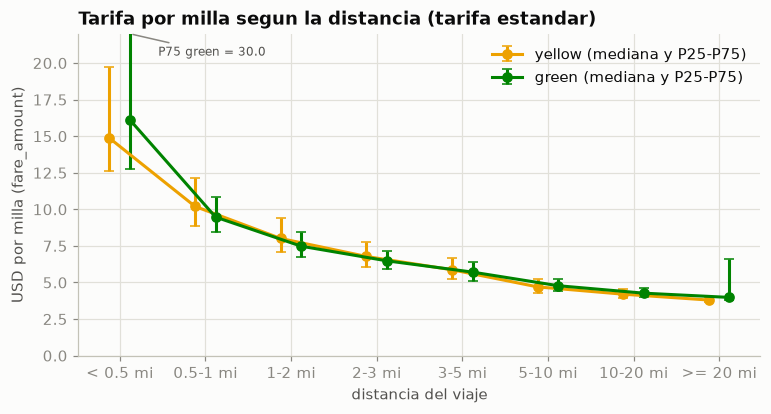

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.8))
for tipo, desplazamiento in [("yellow", -0.12), ("green", 0.12)]:
    d = tarifa_milla[tarifa_milla.tipo == tipo]
    x = [i + desplazamiento for i in range(len(d))]
    ax.errorbar(x, d.usd_por_milla_mediana,
                yerr=[d.usd_por_milla_mediana - d.usd_por_milla_p25, d.usd_por_milla_p75 - d.usd_por_milla_mediana],
                fmt="o-", color=COLOR_TIPO[tipo], markersize=6, capsize=3, label=f"{tipo} (mediana y P25-P75)")
etiquetas = [r.split(") ")[1] for r in tarifa_milla[tarifa_milla.tipo == "yellow"].rango_distancia]
ax.set_xticks(range(len(etiquetas)), etiquetas)
ax.set_xlabel("distancia del viaje")
ax.set_ylabel("USD por milla (fare_amount)")
ax.set_ylim(0, 22)
p75_green = tarifa_milla[tarifa_milla.tipo == "green"].usd_por_milla_p75.iloc[0]
ax.annotate(f"P75 green = {p75_green:.1f}", xy=(0.12, 22), xytext=(0.45, 20.5),
            fontsize=8, color=TINTA_2, arrowprops={"arrowstyle": "-", "color": GRIS})
ax.set_title("Tarifa por milla segun la distancia (tarifa estandar)")
ax.legend(loc="upper right")
guardar(fig, "ej4_p5_tarifa_por_milla")

-- Ejercicio 4 - Pregunta 5 (distribucion): tarifa por milla y velocidad segun la hora
-- Objetivo: verificar si una milla cuesta mas en las horas de mayor trafico.
--           El taximetro cobra por distancia y tambien por tiempo detenido o
--           a baja velocidad, por lo que la congestion deberia encarecer la
--           milla. Se acompania de la velocidad mediana como medida de trafico.
-- Fuente:   vista viajes_validos (00_vistas.sql)
-- Nota:     solo yellow, tarifa estandar (codigo_tarifa = 1) y viajes de
--           1 a 5 millas, para comparar viajes de longitud parecida y aislar
--           el efecto de la hora del efecto de la distancia (consulta 17).


-- tiempo: 1.74 s


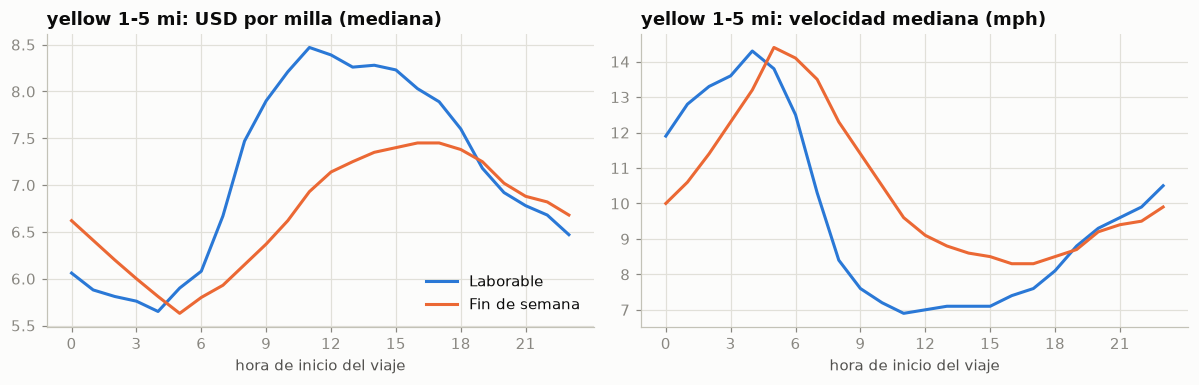

In [25]:
milla_hora = ejecutar("18_tarifa_por_milla_por_hora.sql")
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.6), sharex=True)
for color, tipo_dia in zip(SERIES, ["Laborable", "Fin de semana"]):
    g = milla_hora[milla_hora.tipo_dia == tipo_dia]
    ejes[0].plot(g.hora, g.usd_por_milla_mediana, color=color, label=tipo_dia)
    ejes[1].plot(g.hora, g.velocidad_mediana_mph, color=color, label=tipo_dia)
ejes[0].set_title("yellow 1-5 mi: USD por milla (mediana)")
ejes[1].set_title("yellow 1-5 mi: velocidad mediana (mph)")
for ax in ejes:
    ax.set_xticks(range(0, 24, 3))
    ax.set_xlabel("hora de inicio del viaje")
ejes[0].legend(loc="lower right")
fig.tight_layout()
guardar(fig, "ej4_p5_milla_y_velocidad_hora")

## Pregunta 6 - ¿Donde se concentran los valores atipicos?

**¿Las inconsistencias detectadas en el Ejercicio 3 se reparten entre todos los
proveedores y meses, o se concentran en alguno?**

*Justificacion:* el Ejercicio 3 cuantifico las inconsistencias pero no su
origen. Cada `VendorID` es un sistema de registro distinto (taximetro y
software); si un error se concentra en un proveedor, es un problema de
captura de datos, y la decision de limpieza debe tenerlo en cuenta.

In [26]:
atipicos = ejecutar("19_atipicos_por_proveedor.sql")
atipicos

-- Ejercicio 4 - Pregunta 6 (atipicos): concentracion de inconsistencias por proveedor
-- Objetivo: calcular, para cada proveedor (VendorID) de cada tipo de taxi,
--           el porcentaje de sus viajes que rompe cada regla de calidad del
--           Ejercicio 3, para saber si los errores son generales o vienen de
--           un sistema de registro en particular.
-- Fuente:   vista viajes (00_vistas.sql; SIN filtrar, se buscan los invalidos)
-- Nota:     proveedores: 1 Creative Mobile Technologies, 2 Curb Mobility,
--           6 Myle Technologies, 7 Helix. Las reglas no son excluyentes.
--           'participacion_en_regla' = de todos los viajes que rompen la regla
--           (en ese tipo de taxi), que porcentaje aporta el proveedor.


-- tiempo: 3.27 s


,tipo,regla,proveedor,viajes_proveedor,viajes_incumplen,pct_de_sus_viajes,participacion_en_regla,participacion_en_viajes
0,yellow,1 fecha fuera de 2026,1,5467071,0,0.000,0.0,18.4
1,yellow,1 fecha fuera de 2026,2,23809774,17,0.000,100.0,80.2
2,yellow,1 fecha fuera de 2026,6,59390,0,0.000,0.0,0.2
3,yellow,1 fecha fuera de 2026,7,367120,0,0.000,0.0,1.2
4,yellow,2 duracion cero o negativa,1,5467071,4301,0.079,1.2,18.4
5,yellow,2 duracion cero o negativa,2,23809774,258,0.001,0.1,80.2
6,yellow,2 duracion cero o negativa,6,59390,4,0.007,0.0,0.2
7,yellow,2 duracion cero o negativa,7,367120,367120,100.000,98.8,1.2
8,yellow,3 duracion mayor a 24 h,1,5467071,56,0.001,21.3,18.4
9,yellow,3 duracion mayor a 24 h,2,23809774,205,0.001,77.9,80.2


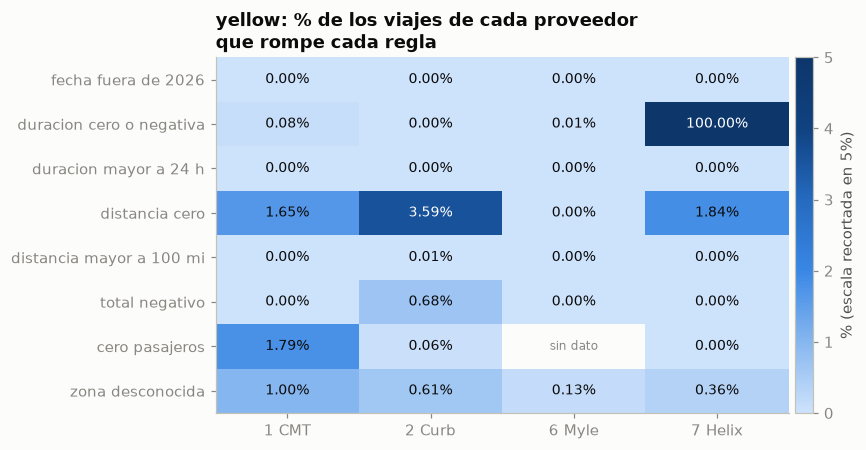

In [27]:
d = atipicos[atipicos.tipo == "yellow"].pivot(index="regla", columns="proveedor", values="pct_de_sus_viajes")
nombres = {1: "1 CMT", 2: "2 Curb", 6: "6 Myle", 7: "7 Helix"}
fig, ax = plt.subplots(figsize=(8, 4.2))
img = ax.imshow(d.clip(upper=5).values, aspect="auto", cmap=AZUL_SECUENCIAL, vmin=0, vmax=5)
for i in range(d.shape[0]):
    for j in range(d.shape[1]):
        valor = d.values[i, j]
        if pd.notna(valor):
            ax.text(j, i, f"{valor:.2f}%", ha="center", va="center", fontsize=9,
                    color="#ffffff" if min(valor, 5) > 2.5 else TINTA)
        else:
            # Myle (6) no registra pasajeros en yellow: no hay viajes evaluables
            ax.text(j, i, "sin dato", ha="center", va="center", fontsize=8, color=GRIS)
ax.set_xticks(range(d.shape[1]), [nombres[p] for p in d.columns])
ax.set_yticks(range(d.shape[0]), [r[2:] for r in d.index])
ax.grid(False)
ax.set_title("yellow: % de los viajes de cada proveedor\nque rompe cada regla")
fig.colorbar(img, ax=ax, label="% (escala recortada en 5%)", pad=0.01)
guardar(fig, "ej4_p6_atipicos_proveedor")

In [28]:
ejecutar("20_atipicos_por_mes.sql")

-- Ejercicio 4 - Pregunta 6 (atipicos): evolucion mensual de las inconsistencias
-- Objetivo: verificar si las tasas de error son estables en el tiempo o si
--           aparecen/desaparecen en algun mes para algun proveedor (taxis
--           amarillos, que concentran el volumen).
-- Fuente:   vista viajes (00_vistas.sql; SIN filtrar)
-- Nota:     se agrupa por el mes del archivo (no por la fecha del viaje),
--           porque una fecha invalida es justamente uno de los errores.


-- tiempo: 1.82 s


,mes,proveedor,viajes,pct_duracion_cero,pct_distancia_cero,viajes_distancia_mayor_100,pct_total_negativo,pct_zona_desconocida
0,2026-01,1,710425,0.045,1.401,10,0.000,1.148
1,2026-01,2,2965742,0.001,3.876,151,1.348,0.571
2,2026-01,6,4017,0.000,0.000,0,0.000,0.249
3,2026-01,7,44705,100.000,1.845,1,0.000,0.344
4,2026-02,1,637609,0.051,1.457,20,0.000,1.100
5,2026-02,2,2716417,0.001,4.175,152,1.005,0.542
6,2026-02,6,5599,0.000,0.000,0,0.000,0.143
7,2026-02,7,40241,100.000,1.394,0,0.000,0.383
8,2026-03,1,764424,0.038,1.562,17,0.000,0.934
9,2026-03,2,3129775,0.001,3.451,143,0.681,0.528


In [29]:
ejecutar("21_distancias_extremas.sql")

-- Ejercicio 4 - Pregunta 6 (atipicos): perfil de los viajes con distancia mayor a 100 millas
-- Objetivo: caracterizar los viajes con distancias imposibles para entender
--           su origen: proveedor, metodo de pago, duracion y tarifa cobrada.
--           Si la tarifa y la duracion son normales, el error esta en el
--           odometro/distancia y no en el viaje.
-- Fuente:   vista viajes + vista metodos_pago (00_vistas.sql; SIN filtrar)


-- tiempo: 1.70 s


,tipo,proveedor,metodo_pago,viajes,distancia_mediana,distancia_maxima,duracion_mediana_min,tarifa_mediana,velocidad_implicita_mph
0,yellow,2,Flex Fare,762,87993.0,328522.0,24.0,33.20,214001.0
1,yellow,2,Efectivo,200,128.0,51422.0,160.3,600.00,49.0
2,yellow,2,Tarjeta,93,129.0,98774.0,119.6,300.00,57.0
3,yellow,1,Tarjeta,79,151.0,246.0,30.2,26.50,303.0
4,yellow,1,Flex Fare,31,152.0,274.0,14.2,15.81,670.0
5,yellow,1,Efectivo,25,127.0,213.0,228.0,222.00,29.0
6,yellow,2,Disputa,18,195.0,274.0,199.8,0.00,54.0
7,yellow,1,Disputa,6,119.0,180.0,154.2,375.00,47.0
8,yellow,2,Sin cargo,4,107.0,113.0,143.0,0.00,46.0
9,yellow,7,Tarjeta,3,121.0,190.0,0.0,438.40,NaN
